### Machine Learning UberEatsCase EDA (Exploratory Data Analysis)

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [5]:
df = pd.read_csv("dataset.csv")
print(df.head())

  Customer placed order datetime Placed order with restaurant datetime  \
0                    01 00:00:47                           01 01:44:06   
1                    01 00:03:15                           01 00:07:22   
2                    01 00:03:54                           01 00:12:37   
3                    01 00:04:46                           01 00:07:26   
4                    01 00:04:49                           01 00:07:40   

  Driver at restaurant datetime Delivered to consumer datetime  Driver ID  \
0                   01 01:53:24                    01 02:11:35        216   
1                           NaN                    01 00:28:17        259   
2                           NaN                    01 01:06:19         66   
3                           NaN                    01 00:49:43        313   
4                   01 00:17:50                    01 00:46:26        133   

   Restaurant ID  Consumer ID Delivery Region  Is ASAP  Order total  \
0             59     

In [6]:
df.describe()

,Driver ID,Restaurant ID,Consumer ID,Order total,Amount of discount,Amount of tip,Refunded amount
count,18078.000000,18078.000000,18078.000000,18078.000000,18078.000000,18078.000000,18078.000000
mean,222.448169,108.721263,32010.313475,51.261496,1.356706,3.492022,0.612091
std,105.219194,98.609766,42010.215766,50.599675,6.516667,3.700115,6.073104
min,7.000000,2.000000,5.000000,0.000000,0.000000,0.000000,0.000000
25%,141.000000,23.000000,4243.500000,26.660000,0.000000,1.400000,0.000000
50%,227.000000,77.000000,10972.000000,38.630000,0.000000,2.550000,0.000000
75%,314.000000,186.000000,56857.000000,57.885000,0.000000,4.460000,0.000000
max,438.000000,409.000000,200449.000000,1604.130000,187.880000,120.300000,414.770000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18078 entries, 0 to 18077
Data columns (total 13 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Customer placed order datetime         18078 non-null  str    
 1   Placed order with restaurant datetime  18038 non-null  str    
 2   Driver at restaurant datetime          13547 non-null  str    
 3   Delivered to consumer datetime         18078 non-null  str    
 4   Driver ID                              18078 non-null  int64  
 5   Restaurant ID                          18078 non-null  int64  
 6   Consumer ID                            18078 non-null  int64  
 7   Delivery Region                        18052 non-null  str    
 8   Is ASAP                                18078 non-null  bool   
 9   Order total                            18078 non-null  float64
 10  Amount of discount                     18078 non-null  float64
 11  Amount of tip

In [8]:
df.isnull().sum()

Customer placed order datetime              0
Placed order with restaurant datetime      40
Driver at restaurant datetime            4531
Delivered to consumer datetime              0
Driver ID                                   0
Restaurant ID                               0
Consumer ID                                 0
Delivery Region                            26
Is ASAP                                     0
Order total                                 0
Amount of discount                          0
Amount of tip                               0
Refunded amount                             0
dtype: int64

In [9]:
# Drop baris yang kosong dari Placed order with restaurant date time dan Delivery Region

df.dropna(subset=['Placed order with restaurant datetime', 'Delivery Region'], axis=0, inplace=True)

# Karena kolom 'Driver at restaurant datetime' memiliki terlalu banyak nilai null
# Maka kita drop semua kolomnya
df.drop(columns=['Driver at restaurant datetime'], inplace=True, errors='ignore')


# Mengubah categorical data menjadi numerical data
# sparse_output = False untuk menghasilkan numpy array bukan sparse matrix
encoder = OneHotEncoder(sparse_output=False)

encoded_array = encoder.fit_transform(df[['Delivery Region']])
# mengambil semua value dari 'Delivery Region'
feature_names = encoder.get_feature_names_out(['Delivery Region'])

# Buat data frame baru yang nanti nya akan di join ke df utama
df_region = pd.DataFrame(encoded_array, columns=feature_names)

df = pd.concat([df.reset_index(drop=True), df_region], axis=1)

df.drop(columns=['Delivery Region'], inplace=True)
# Mengubah dari format string seperti "01 00:45:37" menjadi menit
def ke_menit_manual(txt):
    try:
        if pd.isna(txt) or txt == "": return None
        parts = str(txt).split(' ')
        hari = int(parts[0])
        waktu = parts[1].split(':')
        jam = int(waktu[0])
        menit = int(waktu[1])
        detik = int(waktu[2])
        return (hari * 1440) + (jam * 60) + menit + (detik / 60)
    except:
        return None


df['start_min'] = df['Customer placed order datetime'].apply(ke_menit_manual)
df['end_min'] = df['Delivered to consumer datetime'].apply(ke_menit_manual)
df['restaurant_min'] = df['Placed order with restaurant datetime'].apply(ke_menit_manual)

mask_rollover = (df['end_min'] < df['start_min']) & df['end_min'].notna() & df['start_min'].notna()
df.loc[mask_rollover, 'end_min'] += (31 * 1440)

mask_rollover_res = (df['restaurant_min'] < df['start_min']) & df['restaurant_min'].notna() & df['start_min'].notna()
df.loc[mask_rollover_res, 'restaurant_min'] += (31 * 1440)

df['Delivery Time'] = df['end_min'] - df['start_min']

df.drop(columns=['start_min', 'end_min', 'restaurant_min'], inplace=True)

# Filter yang Is ASAP doang
df = df[df['Is ASAP']].copy()
df.reset_index(drop=True, inplace=True)




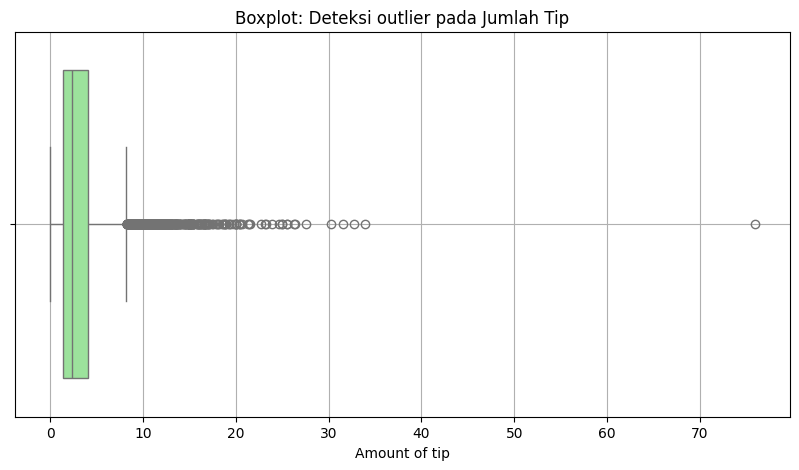

In [10]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['Amount of tip'], color='lightgreen')

plt.title('Boxplot: Deteksi outlier pada Jumlah Tip')
plt.xlabel('Amount of tip')
plt.grid()
plt.show()



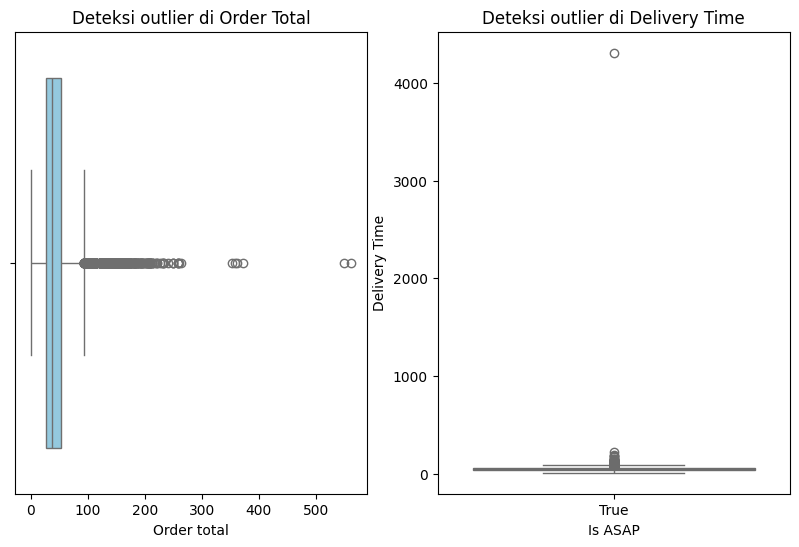

In [11]:
plt.figure(figsize=(10,6))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['Order total'], color='skyblue')
plt.title('Deteksi outlier di Order Total')


plt.subplot(1,2,2)
sns.boxplot(x='Is ASAP',y='Delivery Time', data=df,color='hotpink')
plt.title('Deteksi outlier di Delivery Time')

plt.show()

<Axes: >

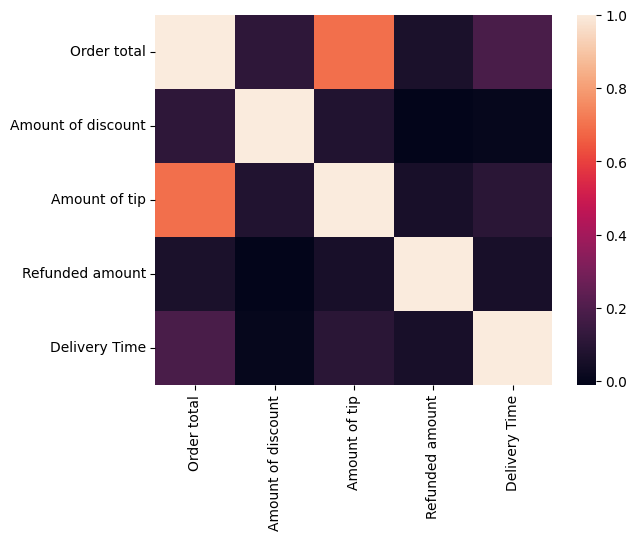

In [12]:
kolom_numerik = [
    'Order total', 
    'Amount of discount', 
    'Amount of tip', 
    'Refunded amount', 
    'Delivery Time'
]

sns.heatmap(df[kolom_numerik].corr())

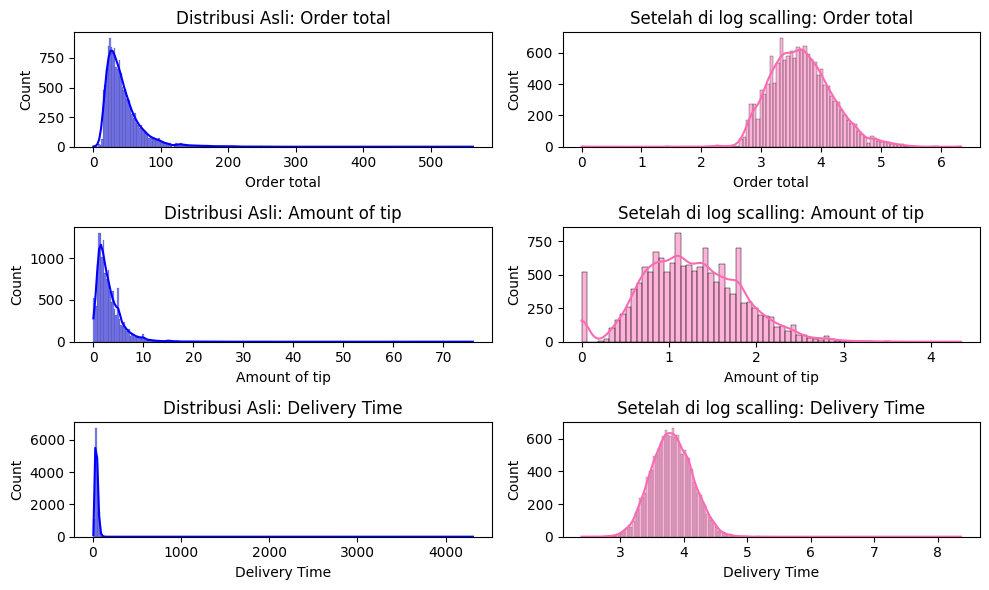

In [13]:
features_to_plot = ['Order total', 'Amount of tip', 'Delivery Time']

plt.figure(figsize=(10,6))

for i, col in enumerate(features_to_plot):
    plt.subplot(3,2, 2*i+1)
    sns.histplot(df[col], kde= True, color='blue')
    plt.title(f'Distribusi Asli: {col}')

    plt.subplot(3, 2, 2*i+2)
    sns.histplot(np.log1p(df[col]), kde=True, color='hotpink')
    plt.title(f'Setelah di log scalling: {col}')
plt.tight_layout()
plt.show()

#Dapat dilihat semuanya itu harus di normaslisasi dengan menggunakan log scalling karena semuanya memiliki power law distribution

### Catatan
**Driver at restaurant datetime** -> drop coloumn, karena tidak penting  
**Delivery Region ama Customer placed order datetime** => drop row

### Tujuan Analisis
1. **Prediksi Amount Of Tip (Y), Order Total(X), Delivery Region(X), (Driver to consumer datetime - Customer placed order datetime)(X)**
2. Customer placed order time (Y),  Delivery Region(X)
3. Order Total harganya(Y), diskon(X) 
